# 02 · Train & Evaluate — YOLOv8 on the façade class contract

**Module 4 · Unit 3 · Session 3**

Trains the detector, extracts the metrics table, saves the curves, and writes
everything into `results/` so the README's claims are generated rather than typed.

---

## Before you press Run all

**Runtime → Change runtime type → T4 GPU.** On CPU this still completes, but slowly.

### Which dataset will this use?

Controlled by `DATASET_SOURCE` in [`src/config.py`](../src/config.py):

| Value | What happens | Needs |
|---|---|---|
| `synthetic` *(default)* | Generates a procedural façade dataset locally | nothing |
| `roboflow` | Downloads your own Roboflow project | API key + workspace/project in config |
| `universe` | Downloads a forked Roboflow Universe project | same |

The default is `synthetic` so that **this notebook runs end to end for a stranger with
no account**. That is the reproducibility requirement, taken literally.

> ⚠️ **Synthetic results are not a performance claim.** They prove the pipeline
> executes. Everything produced from them is stamped `VERIFICATION RUN`. Point
> `DATASET_SOURCE` at a real dataset before quoting a single number as a result.


In [1]:
# ── CELL 1 ── Environment bootstrap. Run this first, every time.
# Works in Colab (clones the repo) and locally (uses the repo you are in).
import os, subprocess, sys, pathlib

REPO_URL = "https://github.com/OmarEAbdelaal/ZIGURAT-AI-AECO-Masters_Group-2.git"
SUBDIR   = "m4u3-facade-ve-vision"   # set to "" if the project is at the repo root

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    root = pathlib.Path('/content') / pathlib.Path(REPO_URL).stem
    if not root.exists():
        subprocess.run(['git', 'clone', '--depth', '1', REPO_URL, str(root)], check=True)
    PROJECT = root / SUBDIR if SUBDIR else root
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r',
                    str(PROJECT / 'requirements.txt')], check=True)
else:
    here = pathlib.Path.cwd()
    PROJECT = next((p for p in [here, *here.parents] if (p / 'src' / 'config.py').exists()), here)

os.chdir(PROJECT)
sys.path.insert(0, str(PROJECT / 'src'))
print('project root :', PROJECT)

import config as C
print()
print(C.summary())


project root : /home/user/ZIGURAT-AI-AECO-Masters_Group-2/m4u3-facade-ve-vision



dataset source   : synthetic
roboflow project : (not configured)
classes (5)     : window, curtain_wall, door, balcony, louvre_screen
model            : yolov8n.pt
epochs/batch/imgsz: 30 / 16 / 640
seed             : 42
conf / iou       : 0.35 / 0.5
ultralytics      : 8.4.157
torch            : 2.14.0+cu130
device           : CPU only
python           : 3.11.15 on Linux-6.18.44-fc-v37-x86_64-with-glibc2.39


## 1 · Roboflow credentials (skip if using the synthetic default)

The API key is read from a **Colab secret**, never typed into a cell and never
committed. Sidebar → 🔑 → new secret named `ROBOFLOW_API_KEY` → enable for this
notebook.


In [2]:
# Uncomment and edit to train on your own Roboflow dataset:
#
# C.DATASET_SOURCE     = 'roboflow'
# C.ROBOFLOW_WORKSPACE = 'your-workspace'
# C.ROBOFLOW_PROJECT   = 'your-project'
# C.ROBOFLOW_VERSION   = 1

print('dataset source :', C.DATASET_SOURCE)
print('api key found  :', bool(C.api_key()))


dataset source : synthetic
api key found  : False


## 2 · Resolve the dataset and run a health check

Session 2's three pillars: quality, structure (the split), consistency. The numbers
below evidence the second and expose the class imbalance that drives the error
analysis later.


In [3]:
import json
from dataset import resolve_dataset, describe

data_yaml = resolve_dataset()
health = describe(data_yaml)
print(json.dumps(health, indent=2))

print()
print('split      :', health['split_ratio'])
print('imbalance  :', health['imbalance_ratio'], ': 1  (most vs least frequent class)')
assert health['splits']['train']['images'] > 0, 'no training images resolved'


synthetic dataset already present -> /home/user/ZIGURAT-AI-AECO-Masters_Group-2/m4u3-facade-ve-vision/data/dataset/synthetic

  NOTE: this is the VERIFICATION dataset. It proves the pipeline runs.
        It is not evidence of real-world façade detection performance.

{
  "yaml": "/home/user/ZIGURAT-AI-AECO-Masters_Group-2/m4u3-facade-ve-vision/data/dataset/synthetic/data.yaml",
  "splits": {
    "train": {
      "images": 96,
      "instances": 2087,
      "unlabelled_images": 0
    },
    "val": {
      "images": 24,
      "instances": 491,
      "unlabelled_images": 0
    }
  },
  "per_class": {
    "train": {
      "window": 1341,
      "curtain_wall": 153,
      "door": 96,
      "balcony": 278,
      "louvre_screen": 219
    },
    "val": {
      "window": 316,
      "curtain_wall": 37,
      "door": 24,
      "balcony": 66,
      "louvre_screen": 48
    },
    "TOTAL": {
      "window": 1657,
      "curtain_wall": 190,
      "door": 120,
      "balcony": 344,
      "louvre_scree

## 3 · Look at the data before training on it

GIGO. Five minutes here saves an afternoon of debugging a model that learned your
labelling mistakes faithfully.


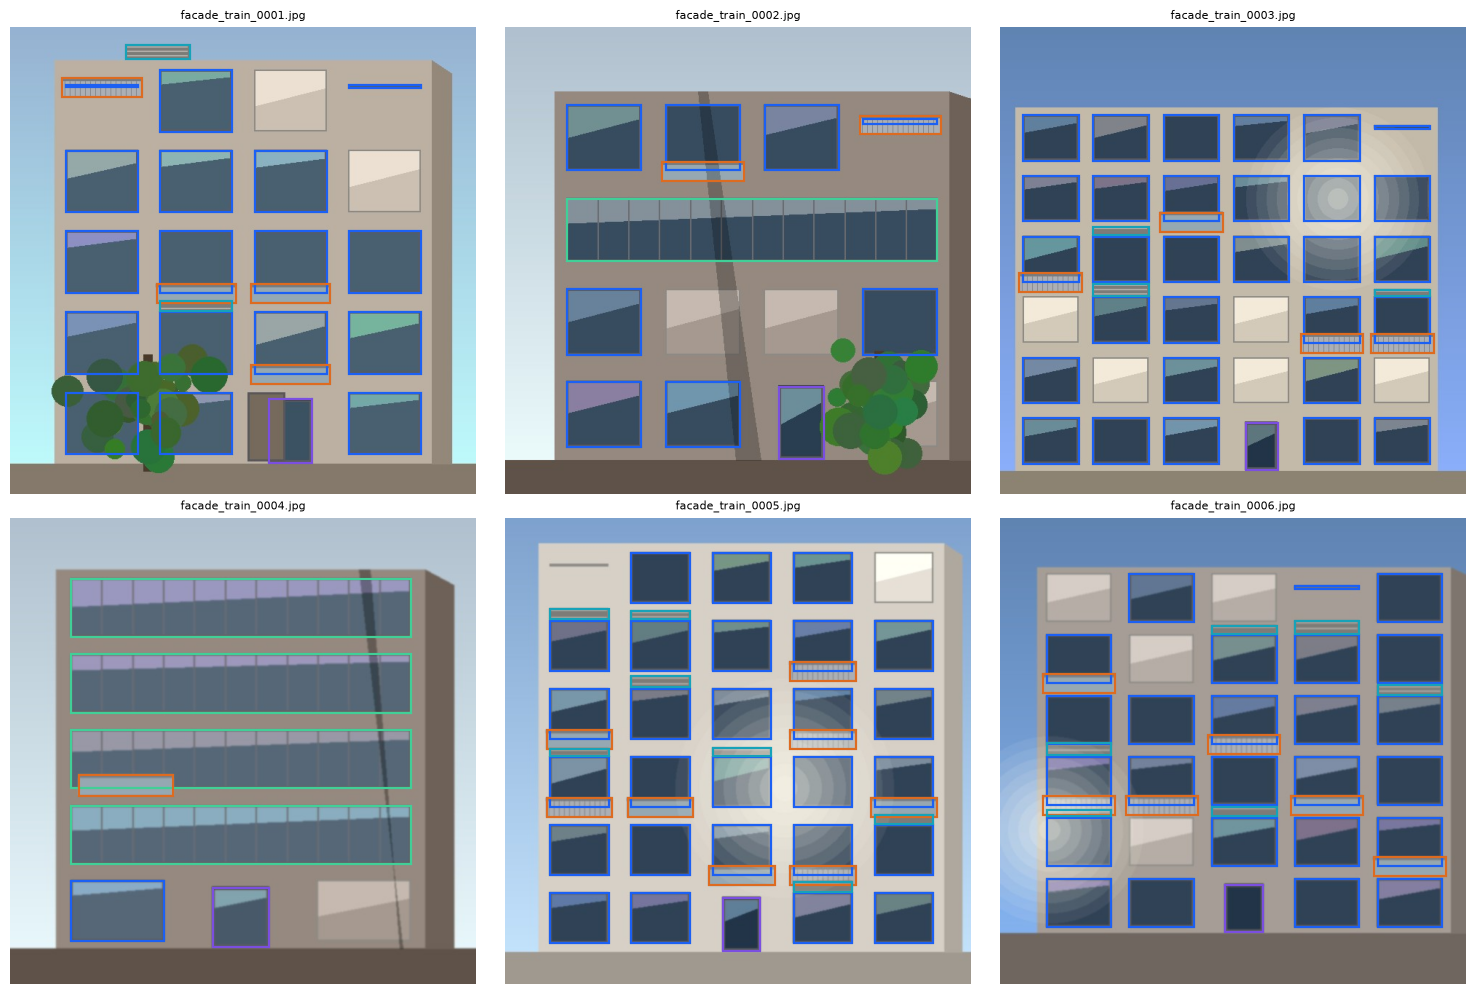

In [4]:
import matplotlib.pyplot as plt, yaml
from PIL import Image
from pathlib import Path
from error_analysis import _load_gt

cfg  = yaml.safe_load(Path(data_yaml).read_text())
root = Path(cfg.get('path', Path(data_yaml).parent))
idir = root / cfg['train']; ldir = idir.parent / 'labels'
samples = sorted(p for p in idir.iterdir() if p.suffix.lower() in ('.jpg','.png'))[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, p in zip(axes.ravel(), samples):
    im = Image.open(p).convert('RGB'); ax.imshow(im)
    for cid, (x0, y0, x1, y1) in _load_gt(ldir / f'{p.stem}.txt', *im.size):
        ax.add_patch(plt.Rectangle((x0, y0), x1-x0, y1-y0, fill=False,
                                   edgecolor=['#1C60F3','#41CF97','#7B4FE0','#DD6B20','#17A2B8'][cid],
                                   linewidth=1.6))
    ax.set_title(p.name, fontsize=8); ax.axis('off')
plt.tight_layout(); plt.show()


## 4 · Train

Every parameter comes from `src/config.py`, so the README's reproducibility table and
the run cannot disagree. The training contract:

| Parameter | Value | Why |
|---|---|---|
| `model` | `yolov8n.pt` | Transfer learning from COCO. Nano first — scale up only if mAP plateaus rather than starting heavy |
| `epochs` | `30` | The brief's minimum. Session 3: under 30 underfits, over 100 memorises |
| `batch` | `16` | Session 3's balance point; fits a free T4 |
| `imgsz` | `640` | Standard. 1280 is for hairline cracks, not for windows |
| `seed` | `42` | Fixed, so a re-run reproduces |
| `patience` | `20` | Early stop — guards the validation-loss 'U-turn' |

**Watch `val/box_loss`.** If training loss falls while validation loss climbs, the
model has started memorising. `patience=20` stops it, but see it happen.


In [5]:
from train import train

run_dir, metrics = train()
print('\nrun directory:', run_dir)


synthetic dataset already present -> /home/user/ZIGURAT-AI-AECO-Masters_Group-2/m4u3-facade-ve-vision/data/dataset/synthetic

  NOTE: this is the VERIFICATION dataset. It proves the pipeline runs.
        It is not evidence of real-world façade detection performance.

{
  "yaml": "/home/user/ZIGURAT-AI-AECO-Masters_Group-2/m4u3-facade-ve-vision/data/dataset/synthetic/data.yaml",
  "splits": {
    "train": {
      "images": 96,
      "instances": 2087,
      "unlabelled_images": 0
    },
    "val": {
      "images": 24,
      "instances": 491,
      "unlabelled_images": 0
    }
  },
  "per_class": {
    "train": {
      "window": 1341,
      "curtain_wall": 153,
      "door": 96,
      "balcony": 278,
      "louvre_screen": 219
    },
    "val": {
      "window": 316,
      "curtain_wall": 37,
      "door": 24,
      "balcony": 66,
      "louvre_screen": 48
    },
    "TOTAL": {
      "window": 1657,
      "curtain_wall": 190,
      "door": 120,
      "balcony": 344,
      "louvre_scree

engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/user/ZIGURAT-AI-AECO-Masters_Group-2/m4u3-facade-ve-vision/data/dataset/synthetic/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=facade_ve_v1, nbs=64, nms=None, opset=None, optimize=False, op

Overriding model.yaml nc=80 with nc=5



                   from  n    params  module                                       arguments                     


  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 


...

               balcony         23         66      0.994       0.97      0.965      0.897


         louvre_screen         19         48      0.971      0.979      0.971      0.764


Speed: 0.9ms preprocess, 56.9ms inference, 0.0ms loss, 12.3ms postprocess per image


Results saved to /home/user/ZIGURAT-AI-AECO-Masters_Group-2/m4u3-facade-ve-vision/runs/detect/val



metrics -> /home/user/ZIGURAT-AI-AECO-Masters_Group-2/m4u3-facade-ve-vision/results/metrics
curves  -> /home/user/ZIGURAT-AI-AECO-Masters_Group-2/m4u3-facade-ve-vision/results/curves

run directory: /home/user/ZIGURAT-AI-AECO-Masters_Group-2/m4u3-facade-ve-vision/runs/detect/facade_ve_v1


## 5 · The metrics table

Precision / Recall / mAP50 / mAP50-95, overall and per class.

**`mAP50-95` is this project's headline number, not `mAP50`.** The VE read-out is
computed from box *area*, so a box 20 % too large is a 20 % cost error that `mAP50`
scores as a clean hit. Only the IoU-strict metric sees it.
See [`docs/problem_framing.md`](../docs/problem_framing.md) §3.


In [6]:
from IPython.display import Markdown, display
display(Markdown((C.METRICS_DIR / 'metrics.md').read_text()))


# Metrics — yolov8n.pt on `synthetic`

> **VERIFICATION RUN — not a performance claim.** These numbers come from the procedural dataset in `src/synthetic_facades.py`, which exists to prove the pipeline executes end to end without credentials. Synthetic façades are axis-aligned and synthetically lit; the domain gap to a photograph is large. Replace with a `DATASET_SOURCE="roboflow"` run before quoting any figure as a result.

Run (UTC): `2026-09-20T20:19:20+00:00` · device: `CPU only` · train time: 489s
`ultralytics 8.4.157` · `torch 2.14.0+cu130`

## Overall (validation split, IoU 0.50)

| Precision | Recall | mAP50 | mAP50-95 |
|---|---|---|---|
| 0.975 | 0.946 | 0.948 | **0.879** |

`mAP50-95` is the headline metric for this project. Value Engineering quantities are
derived from **box area**, so a box that is 20 % too large is a 20 % cost error even
though `mAP50` would still score it a hit. Only the IoU-strict metric penalises that.

## Per class

| Class | Val instances | Precision | Recall | mAP50 | mAP50-95 |
|---|---|---|---|---|---|
| `window` | 316 | 0.980 | 0.951 | 0.985 | **0.951** |
| `curtain_wall` | 37 | 0.980 | 1.000 | 0.995 | **0.976** |
| `door` | 24 | 0.952 | 0.830 | 0.821 | **0.809** |
| `balcony` | 66 | 0.994 | 0.970 | 0.965 | **0.897** |
| `louvre_screen` | 48 | 0.971 | 0.979 | 0.971 | **0.764** |

## Reproduction parameters

| Parameter | Value |
|---|---|
| model | `yolov8n.pt` |
| epochs | 30 |
| batch | 16 |
| imgsz | 640 |
| seed | 42 |
| patience | 20 |
| cos_lr | True |
| ultralytics | `8.4.157` |

<sub>Generated by `src/train.py`. Do not edit by hand — re-run the notebook instead.</sub>


## 6 · The curves — the vitals check

Session 3's three scenarios: the **ski slope** (good), the **flatline** (bad learning
rate or bad labels), the **U-turn** (overfitting — stop).



results.png


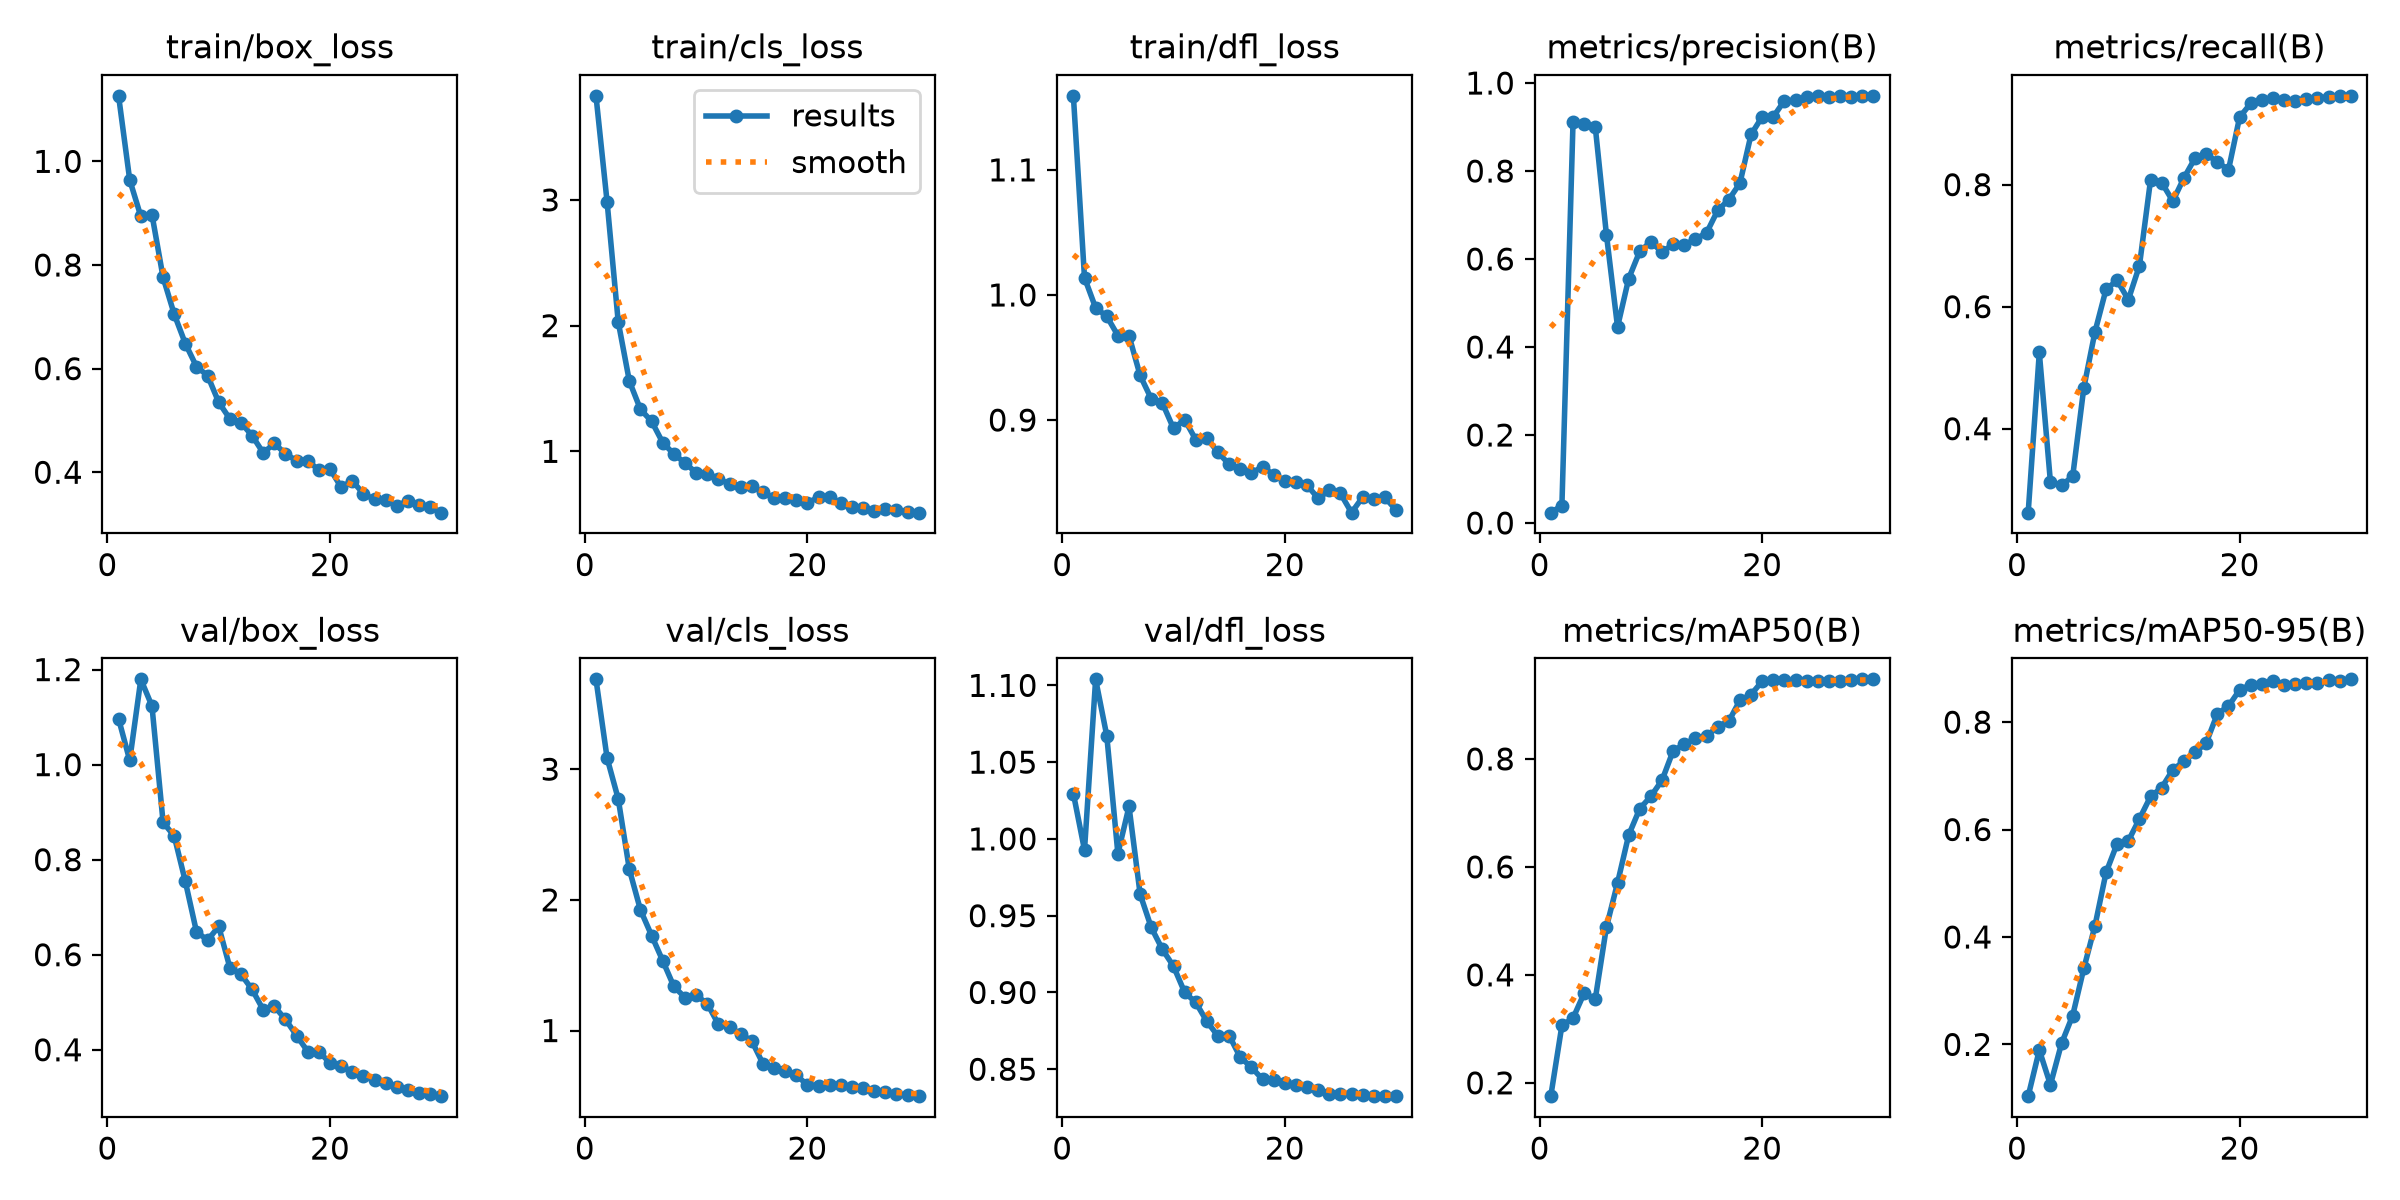


confusion_matrix_normalized.png


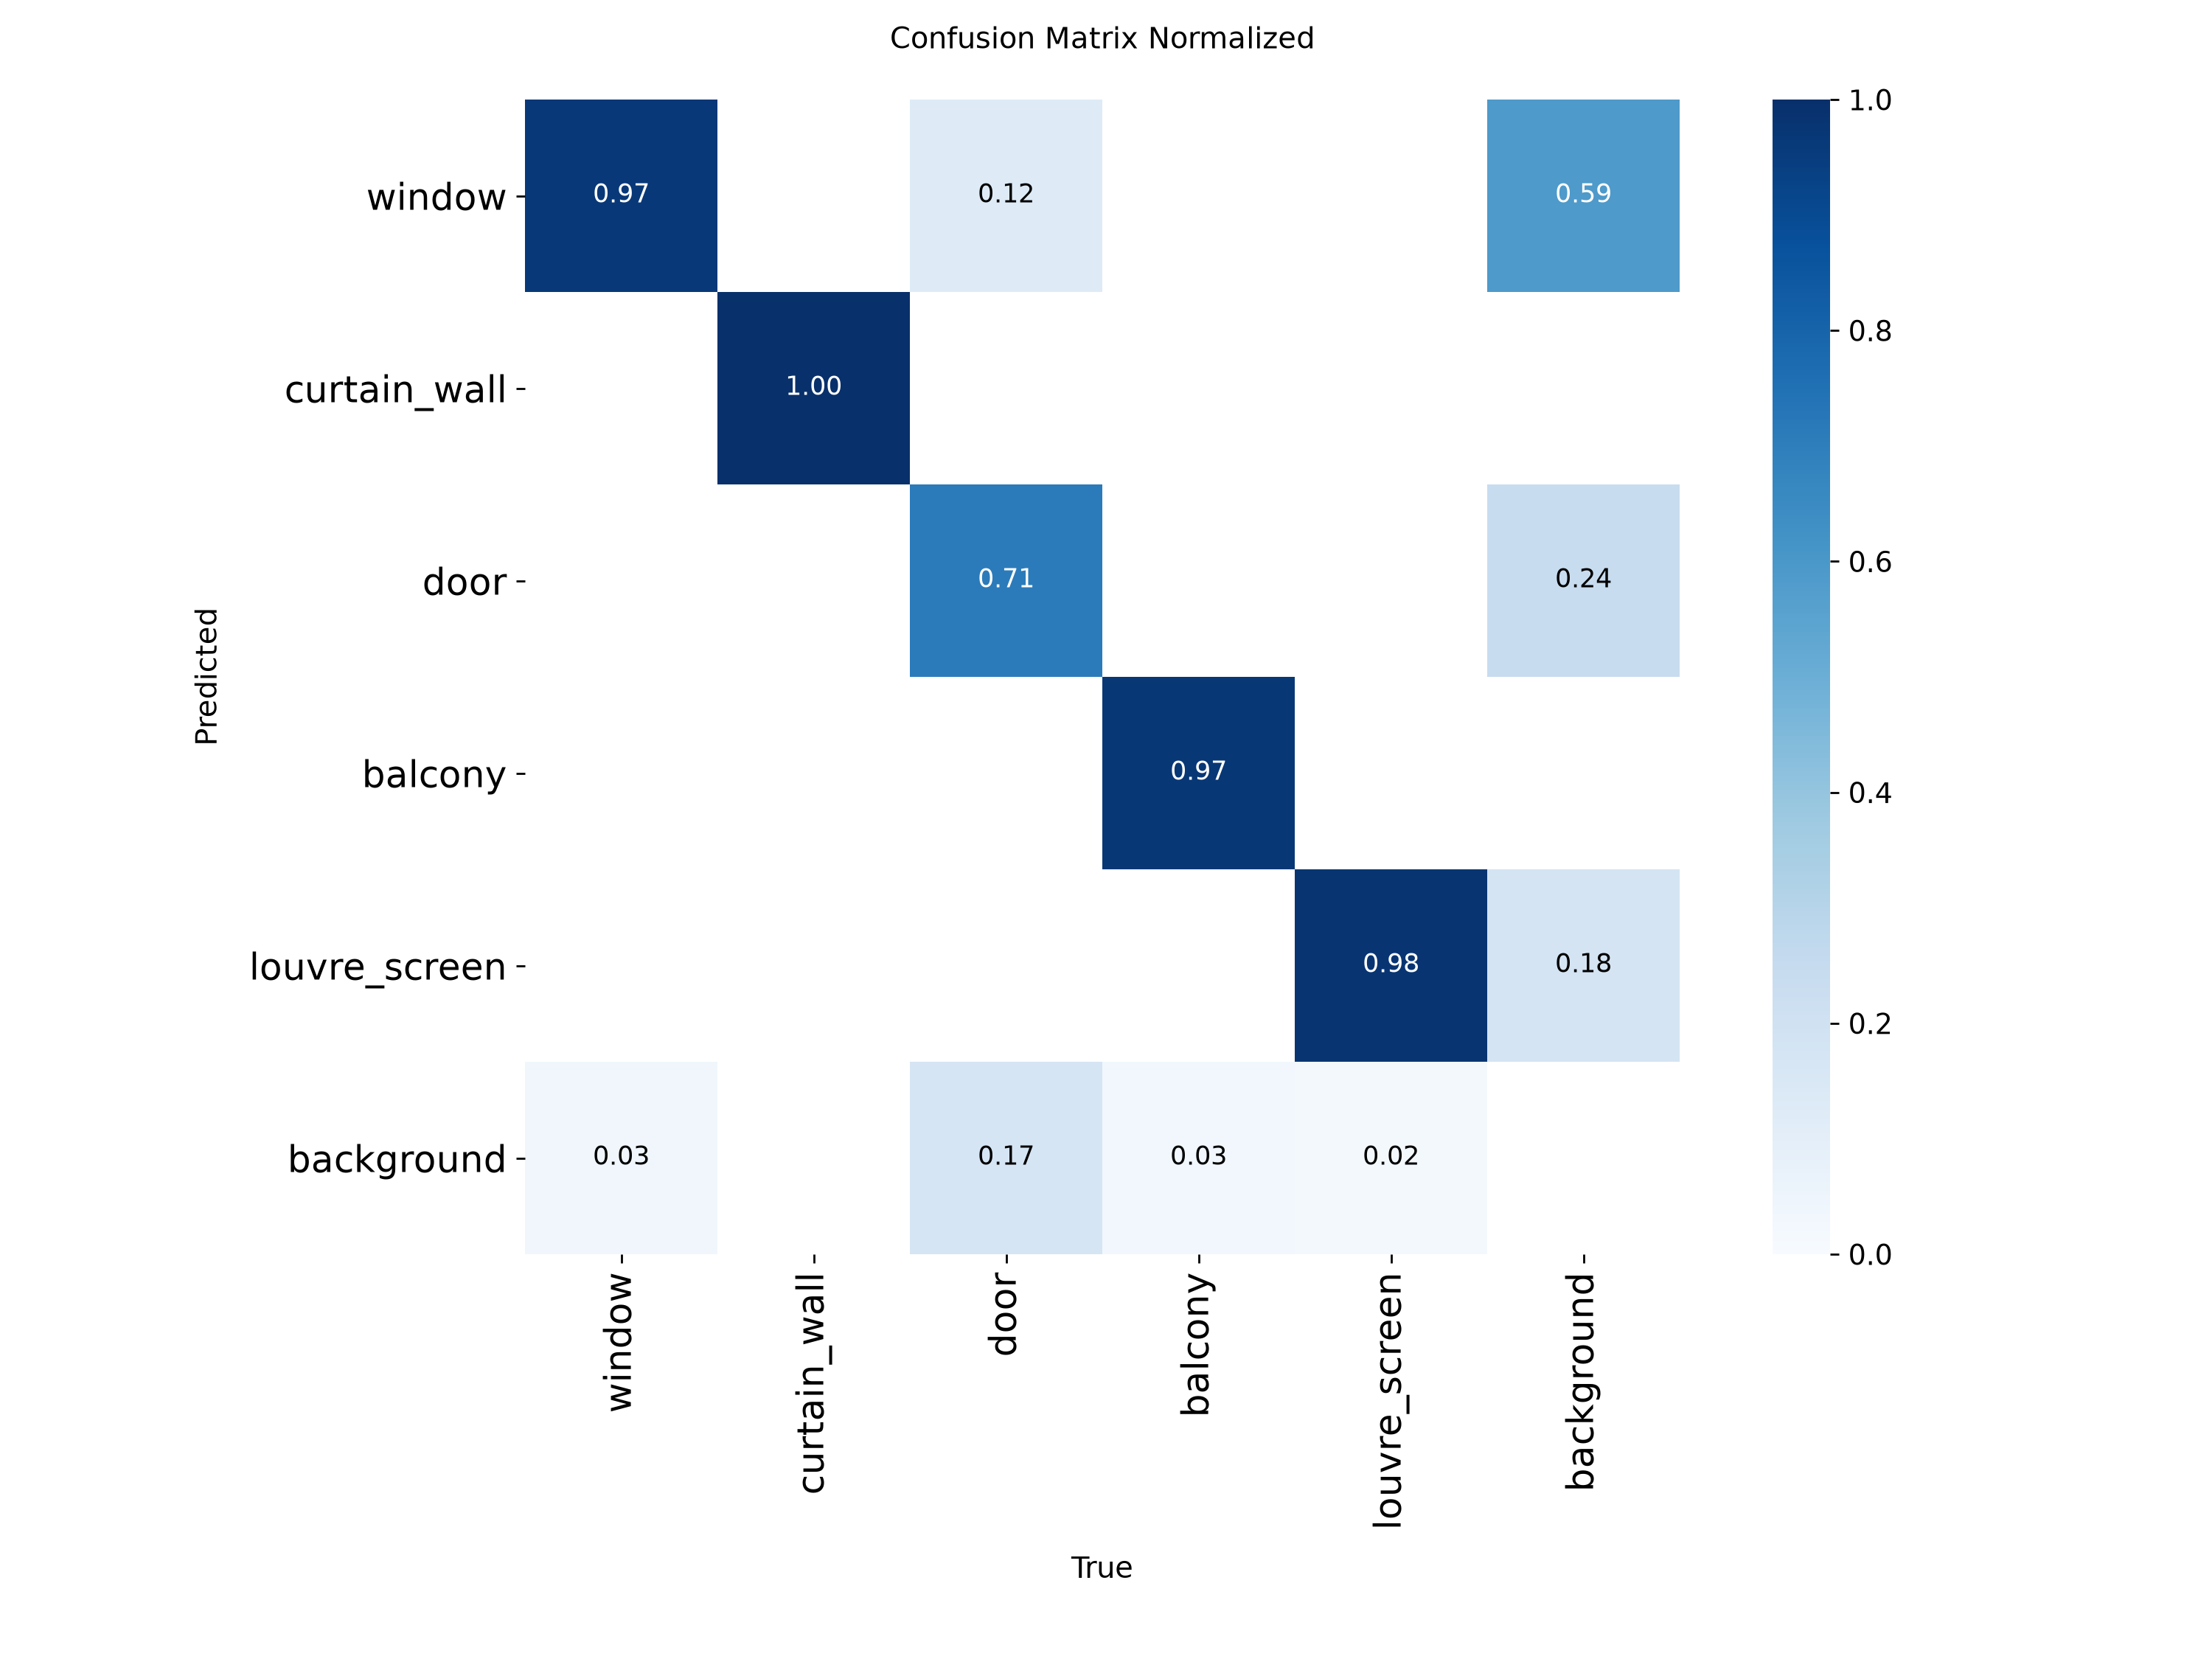


PR_curve.png


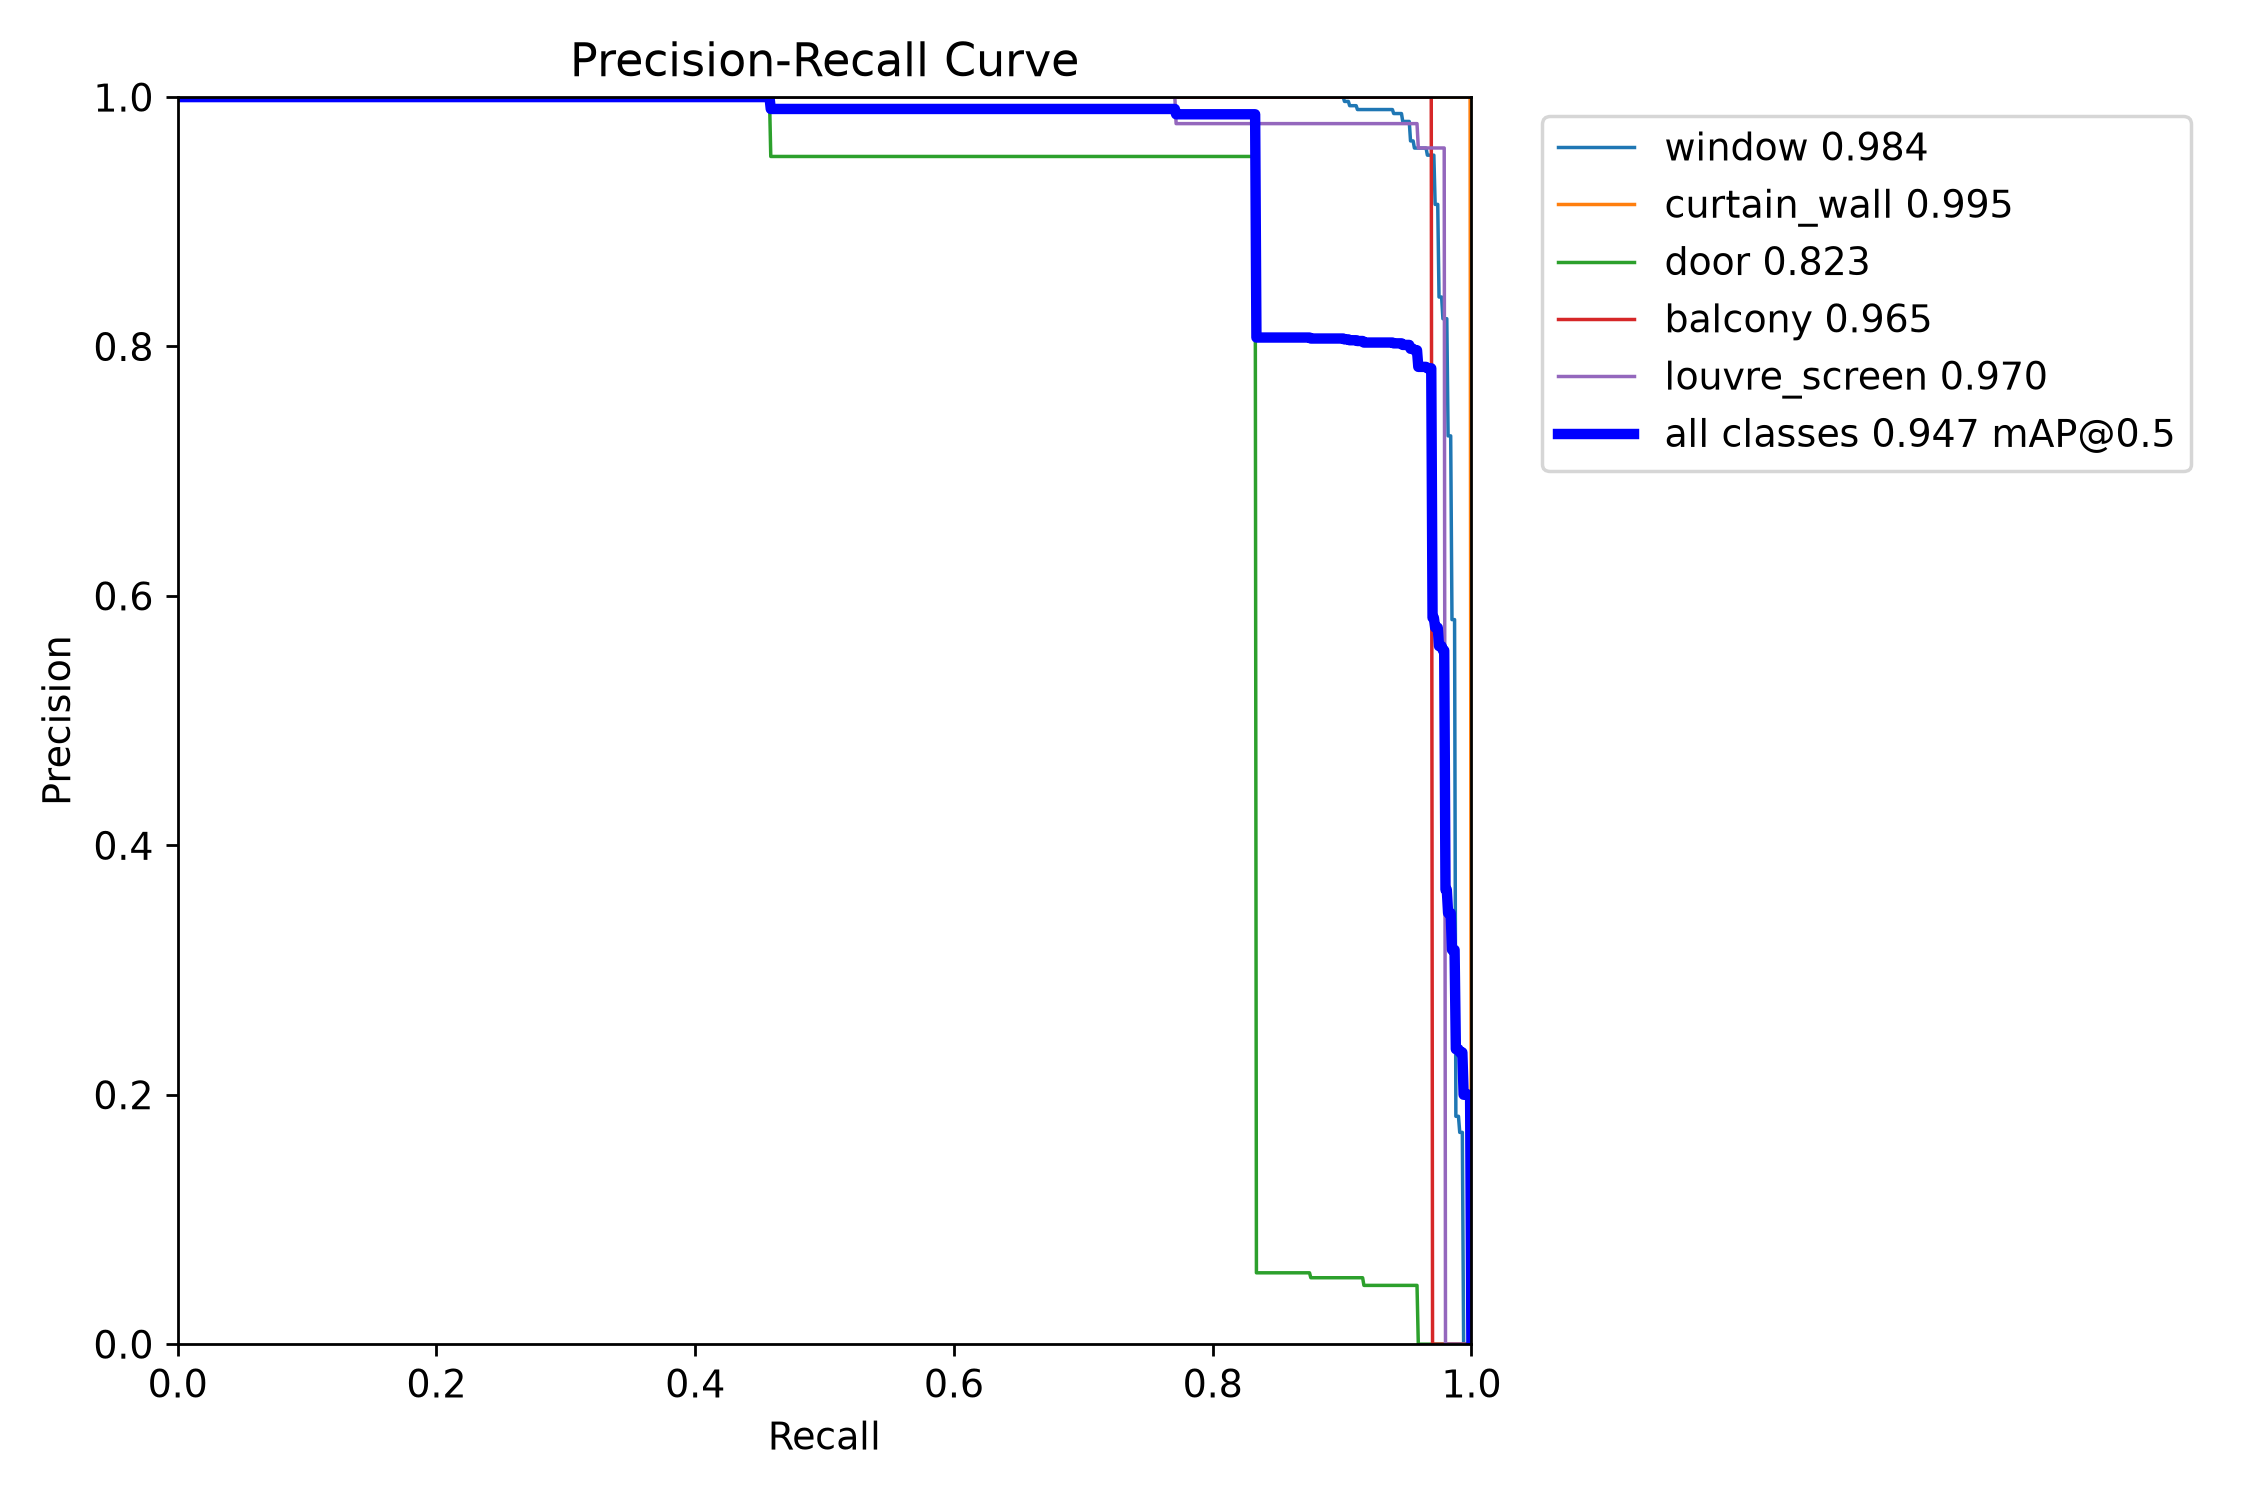

In [7]:
from IPython.display import Image as IPImage, display
for name in ['results.png', 'confusion_matrix_normalized.png', 'PR_curve.png']:
    f = C.CURVES_DIR / name
    if f.exists():
        print(f'\n{name}')
        display(IPImage(filename=str(f), width=900))


## 7 · Where the weights went

`best.pt`, not `last.pt`. `last.pt` is wherever training happened to stop; `best.pt`
is the epoch that scored highest on validation.

**Publish it as a GitHub Release asset** and paste the URL into `WEIGHTS_URL` in
`src/config.py` — that is how a reader runs notebook `03` without training.


In [8]:
w = C.RESULTS_DIR / 'weights' / 'best.pt'
print('weights :', w)
print('exists  :', w.exists())
print('size    :', f'{w.stat().st_size/1e6:.1f} MB' if w.exists() else '—')
print()
print('Next: notebook 03 builds the evidence pack and mines the error taxonomy.')


weights : /home/user/ZIGURAT-AI-AECO-Masters_Group-2/m4u3-facade-ve-vision/results/weights/best.pt
exists  : True
size    : 6.2 MB

Next: notebook 03 builds the evidence pack and mines the error taxonomy.
